In [ ]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, label_binarize, StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingRegressor, GradientBoostingClassifier, RandomForestRegressor
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve,
    auc)
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from datetime import datetime
from sklearn.compose import ColumnTransformer
from imblearn.over_sampling import SMOTE
from joblib import load, dump
import ipywidgets as widgets
from IPython.display import display
from sklearn.pipeline import Pipeline
from IPython.display import display
import ipywidgets as widgets
from IPython.display import display

In [ ]:
# Load Dataset

dataset = pd.read_csv("UberDataset.csv")
dataset.head()

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01-01-2016 21:11,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01-02-2016 01:25,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,NaN
2,01-02-2016 20:25,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01-05-2016 17:31,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01-06-2016 14:42,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit


In [ ]:
# Shape of dataset

dataset.shape

(1156, 7)

In [ ]:
# Information of dataset

dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1156 entries, 0 to 1155
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   START_DATE  1156 non-null   object 
 1   END_DATE    1155 non-null   object 
 2   CATEGORY    1155 non-null   object 
 3   START       1155 non-null   object 
 4   STOP        1155 non-null   object 
 5   MILES       1156 non-null   float64
 6   PURPOSE     653 non-null    object 
dtypes: float64(1), object(6)
memory usage: 63.3+ KB


### **Data Preprocessing**

In [ ]:
# Null values in PURPOSE column filling with Not_Shared

dataset['PURPOSE'].fillna("Not_Shared", inplace =True)

/tmp/ipython-input-4151031624.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset['PURPOSE'].fillna("Not_Shared", inplace =True)


In [ ]:
# Changing the format of START_DATE

dataset['START_DATE'] = pd.to_datetime(dataset['START_DATE'], errors='coerce')
dataset.START_DATE.head()

,START_DATE
0,2016-01-01 21:11:00
1,2016-01-02 01:25:00
2,2016-01-02 20:25:00
3,2016-01-05 17:31:00
4,2016-01-06 14:42:00


In [ ]:
# Changing the format of END_DATE

dataset['END_DATE'] = pd.to_datetime(dataset['END_DATE'], errors='coerce')
dataset.END_DATE.head()

,END_DATE
0,2016-01-01 21:17:00
1,2016-01-02 01:37:00
2,2016-01-02 20:38:00
3,2016-01-05 17:45:00
4,2016-01-06 15:49:00


In [ ]:
# Splitting the START_DATE to date and time column

dataset['Date'] = pd.DatetimeIndex(dataset['START_DATE']).date
dataset['Time'] = pd.DatetimeIndex(dataset['START_DATE']).hour
dataset['Day_Night'] = pd.cut(x=dataset['Time'],
                              bins = [0,10,15,19,24],
                              labels = ['Morning','Noon','Evening','Night'])
dataset.head()

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,Date,Time,Day_Night
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,2016-01-01,21.0,Night
1,2016-01-02 01:25:00,2016-01-02 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,Not_Shared,2016-01-02,1.0,Morning
2,2016-01-02 20:25:00,2016-01-02 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,2016-01-02,20.0,Night
3,2016-01-05 17:31:00,2016-01-05 17:45:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting,2016-01-05,17.0,Evening
4,2016-01-06 14:42:00,2016-01-06 15:49:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit,2016-01-06,14.0,Noon


In [ ]:
# Drop rows with null values

dataset.dropna(inplace=True)

In [ ]:
# Drop the duplicate rows

dataset.drop_duplicates(inplace=True)

In [ ]:
# Date-time format

dataset['START_DATE'] = pd.to_datetime(dataset['START_DATE'], errors='coerce')
dataset['END_DATE']   = pd.to_datetime(dataset['END_DATE'], errors='coerce')
dataset['DURATION_MIN'] = (dataset['END_DATE'] - dataset['START_DATE']).dt.total_seconds()/60
dataset['START_HOUR']       = dataset['START_DATE'].dt.hour
dataset['DAY_OF_WEEK']  = dataset['START_DATE'].dt.dayofweek  # 0=Mon
dataset['MONTH_NUM']  = dataset['START_DATE'].dt.month
dataset['ROUTE']      = dataset['START'] + " → " + dataset['STOP']

df_class = dataset.dropna(subset=['PURPOSE']).copy()

dataset.head()

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,Date,Time,Day_Night,DURATION_MIN,START_HOUR,DAY_OF_WEEK,MONTH_NUM,ROUTE
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,2016-01-01,21.0,Night,6.0,21,4,1,Fort Pierce → Fort Pierce
1,2016-01-02 01:25:00,2016-01-02 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,Not_Shared,2016-01-02,1.0,Morning,12.0,1,5,1,Fort Pierce → Fort Pierce
2,2016-01-02 20:25:00,2016-01-02 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,2016-01-02,20.0,Night,13.0,20,5,1,Fort Pierce → Fort Pierce
3,2016-01-05 17:31:00,2016-01-05 17:45:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting,2016-01-05,17.0,Evening,14.0,17,1,1,Fort Pierce → Fort Pierce
4,2016-01-06 14:42:00,2016-01-06 15:49:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit,2016-01-06,14.0,Noon,67.0,14,2,1,Fort Pierce → West Palm Beach


In [ ]:
# Check unique values

obj = (dataset.dtypes == 'object')
object_cols = list(obj[obj].index)
unique_values = {}
for col in object_cols:
  unique_values[col] = dataset[col].unique().size
unique_values

{'CATEGORY': 2,
 'START': 108,
 'STOP': 112,
 'PURPOSE': 7,
 'Date': 113,
 'ROUTE': 183}

### **Data Visualization**

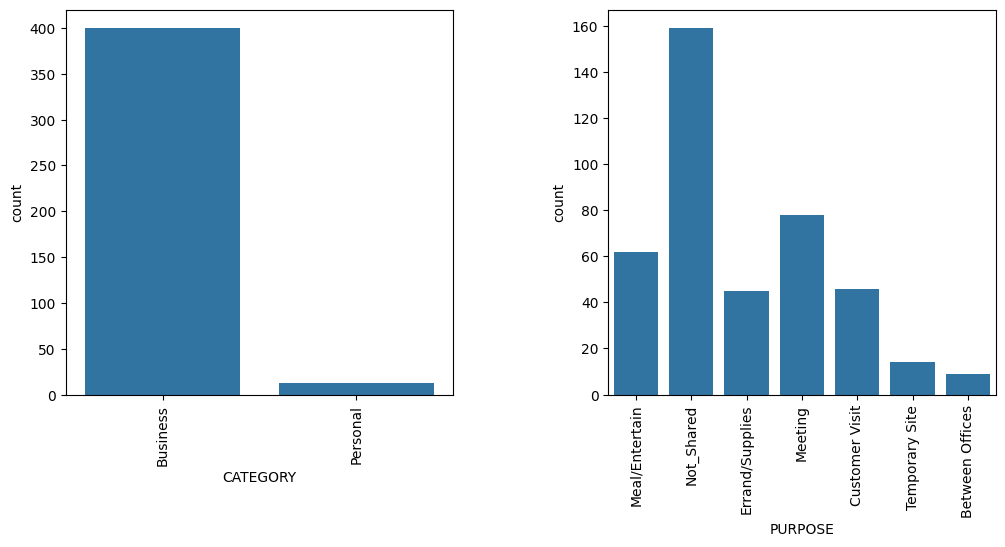

In [ ]:
# Countplot the category and purpose columns

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.countplot(x='CATEGORY', data=dataset)
plt.xticks(rotation=90)

plt.subplot(1, 2, 2)
sns.countplot(x='PURPOSE', data=dataset)
plt.xticks(rotation=90)

plt.subplots_adjust(wspace=0.4)
plt.show()

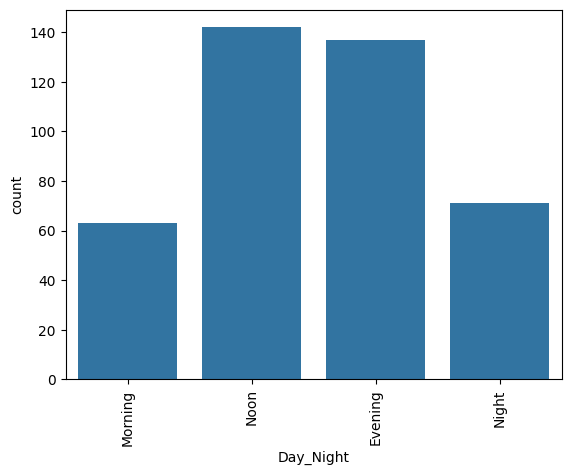

In [ ]:
# Countplot the day-night column

sns.countplot(x='Day_Night', data=dataset)
plt.xticks(rotation=90)
plt.show()

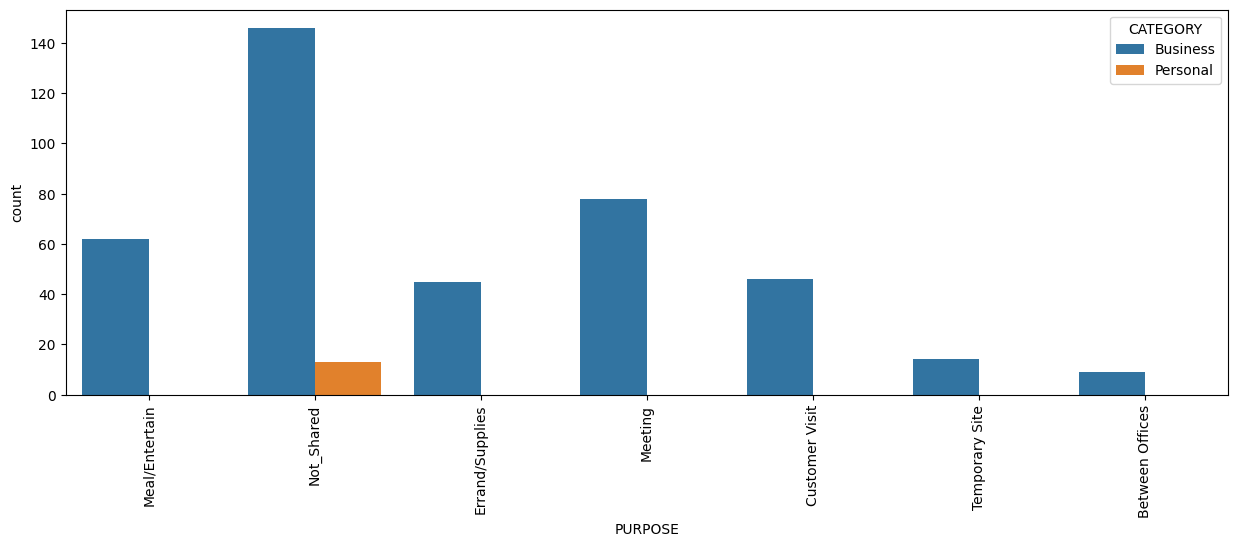

In [ ]:
# Comparing between CATEGORY and PURPOSE

plt.figure(figsize=(15, 5))
sns.countplot(data=dataset, x='PURPOSE', hue='CATEGORY')
plt.xticks(rotation=90)
plt.show()

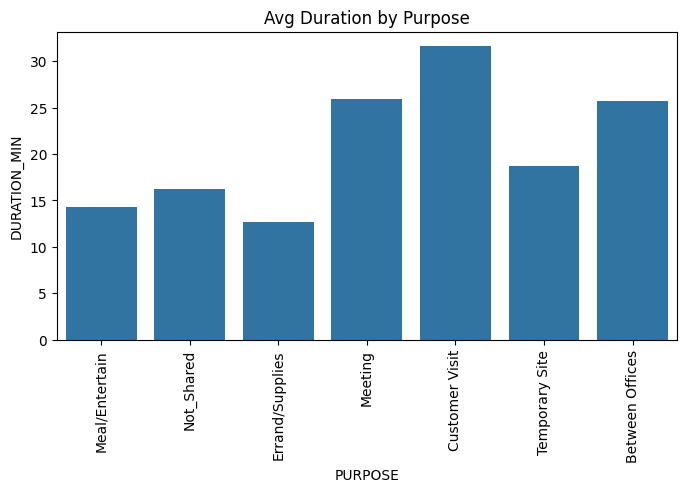

In [ ]:
# Average duration by PURPOSE

plt.figure(figsize=(8,4))
sns.barplot(x='PURPOSE', y='DURATION_MIN', data=dataset, errorbar=None)
plt.xticks(rotation=90);
plt.title("Avg Duration by Purpose");
plt.show()

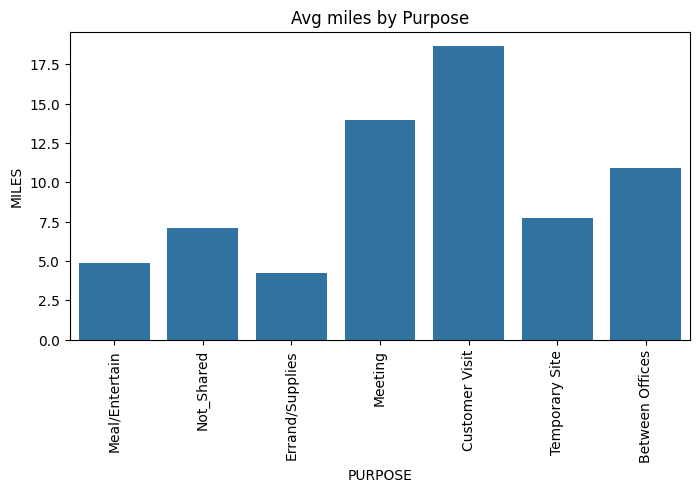

In [ ]:
# Average miles by PURPOSE

plt.figure(figsize=(8,4))
sns.barplot(x='PURPOSE', y='MILES', data=dataset, errorbar=None)
plt.xticks(rotation=90);
plt.title("Avg miles by Purpose");
plt.show()

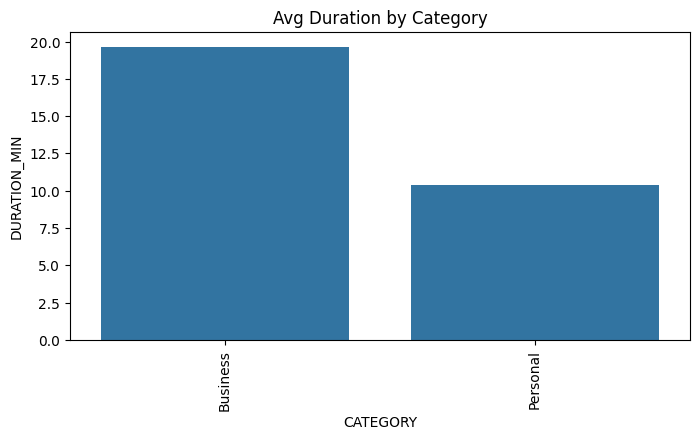

In [ ]:
# Average duration by CATEGORY

plt.figure(figsize=(8,4))
sns.barplot(x='CATEGORY', y='DURATION_MIN', data=dataset, errorbar=None)
plt.xticks(rotation=90);
plt.title("Avg Duration by Category");
plt.show()

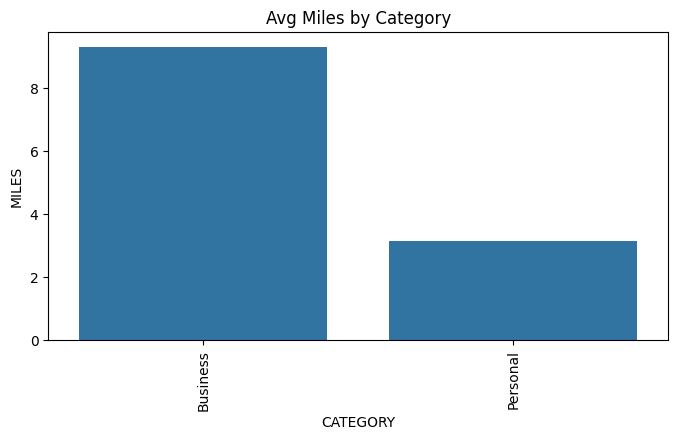

In [ ]:
# Average miles by CATEGORY

plt.figure(figsize=(8,4))
sns.barplot(x='CATEGORY', y='MILES', data=dataset, errorbar=None)
plt.xticks(rotation=90);
plt.title("Avg Miles by Category");
plt.show()

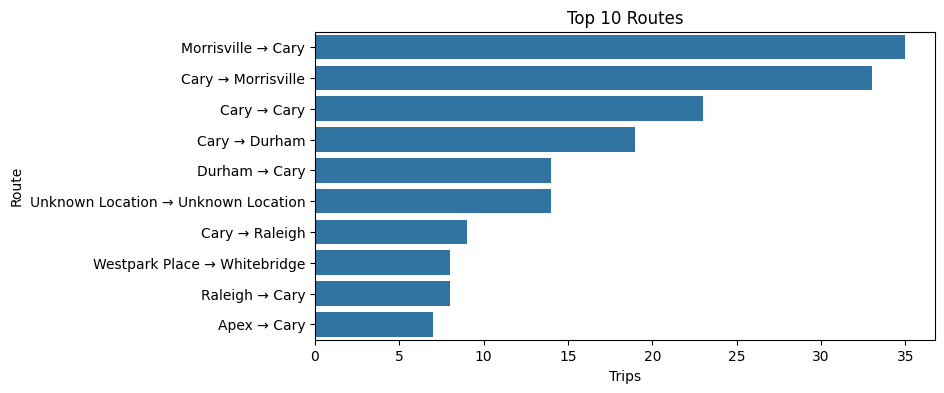

In [ ]:
# Top 10 Routes

top_routes = dataset['ROUTE'].value_counts().head(10)
plt.figure(figsize=(8,4))
sns.barplot(y=top_routes.index, x=top_routes.values)
plt.title("Top 10 Routes");
plt.xlabel("Trips");
plt.ylabel("Route");
plt.show()

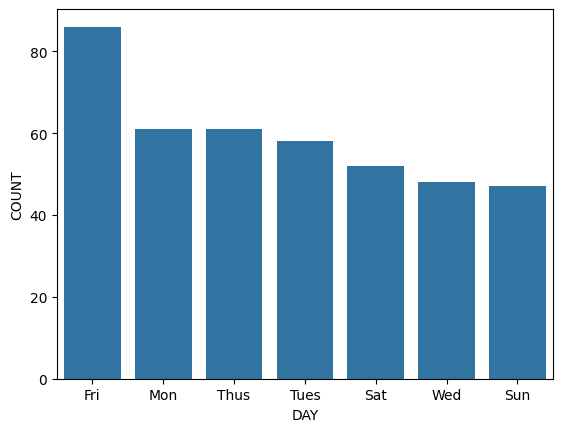

In [ ]:
# Visualize day data

dataset['DAY'] = dataset.START_DATE.dt.weekday
day_label = {
    0: 'Mon', 1: 'Tues', 2: 'Wed', 3: 'Thus', 4: 'Fri', 5: 'Sat', 6: 'Sun'}
dataset['DAY'] = dataset['DAY'].map(day_label)
day_label = dataset.DAY.value_counts()
sns.barplot(x=day_label.index, y=day_label);
plt.xlabel('DAY')
plt.ylabel('COUNT')
plt.show()

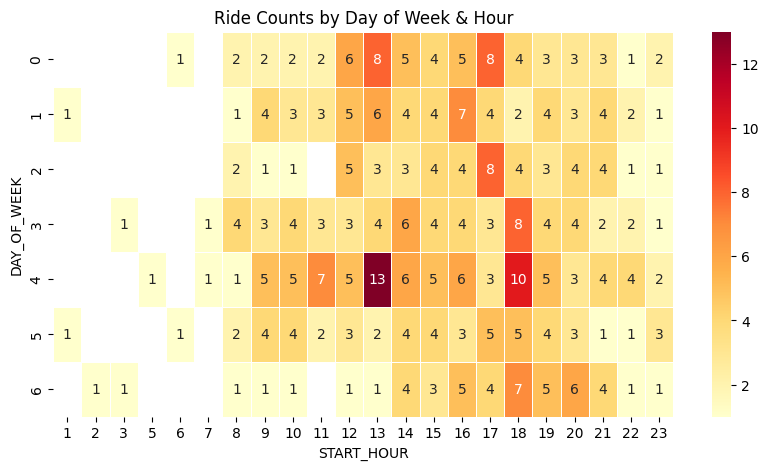

In [ ]:
# Heatmap between Day and hour

rides_pivot = dataset.pivot_table(index='DAY_OF_WEEK', columns='START_HOUR', values='MILES', aggfunc='count')
plt.figure(figsize=(10,5))
sns.heatmap(rides_pivot, cmap='YlOrRd', linewidths=0.5, annot=True, fmt='.0f')
plt.title("Ride Counts by Day of Week & Hour");
plt.show()

In [ ]:
# Using OneHotEncoder to categories CATEGORY and PURPOSE

object_cols = ['CATEGORY', 'PURPOSE']
OH_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
OH_cols = pd.DataFrame(OH_encoder.fit_transform(dataset[object_cols]),
                       index=dataset.index,
                       columns=OH_encoder.get_feature_names_out(object_cols))
dataset = pd.concat([dataset, OH_cols], axis=1)
dataset.head()

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,Date,Time,Day_Night,...,DAY,CATEGORY_Business,CATEGORY_Personal,PURPOSE_Between Offices,PURPOSE_Customer Visit,PURPOSE_Errand/Supplies,PURPOSE_Meal/Entertain,PURPOSE_Meeting,PURPOSE_Not_Shared,PURPOSE_Temporary Site
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,2016-01-01,21.0,Night,...,Fri,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,2016-01-02 01:25:00,2016-01-02 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,Not_Shared,2016-01-02,1.0,Morning,...,Sat,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,2016-01-02 20:25:00,2016-01-02 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,2016-01-02,20.0,Night,...,Sat,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,2016-01-05 17:31:00,2016-01-05 17:45:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting,2016-01-05,17.0,Evening,...,Tues,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,2016-01-06 14:42:00,2016-01-06 15:49:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit,2016-01-06,14.0,Noon,...,Wed,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


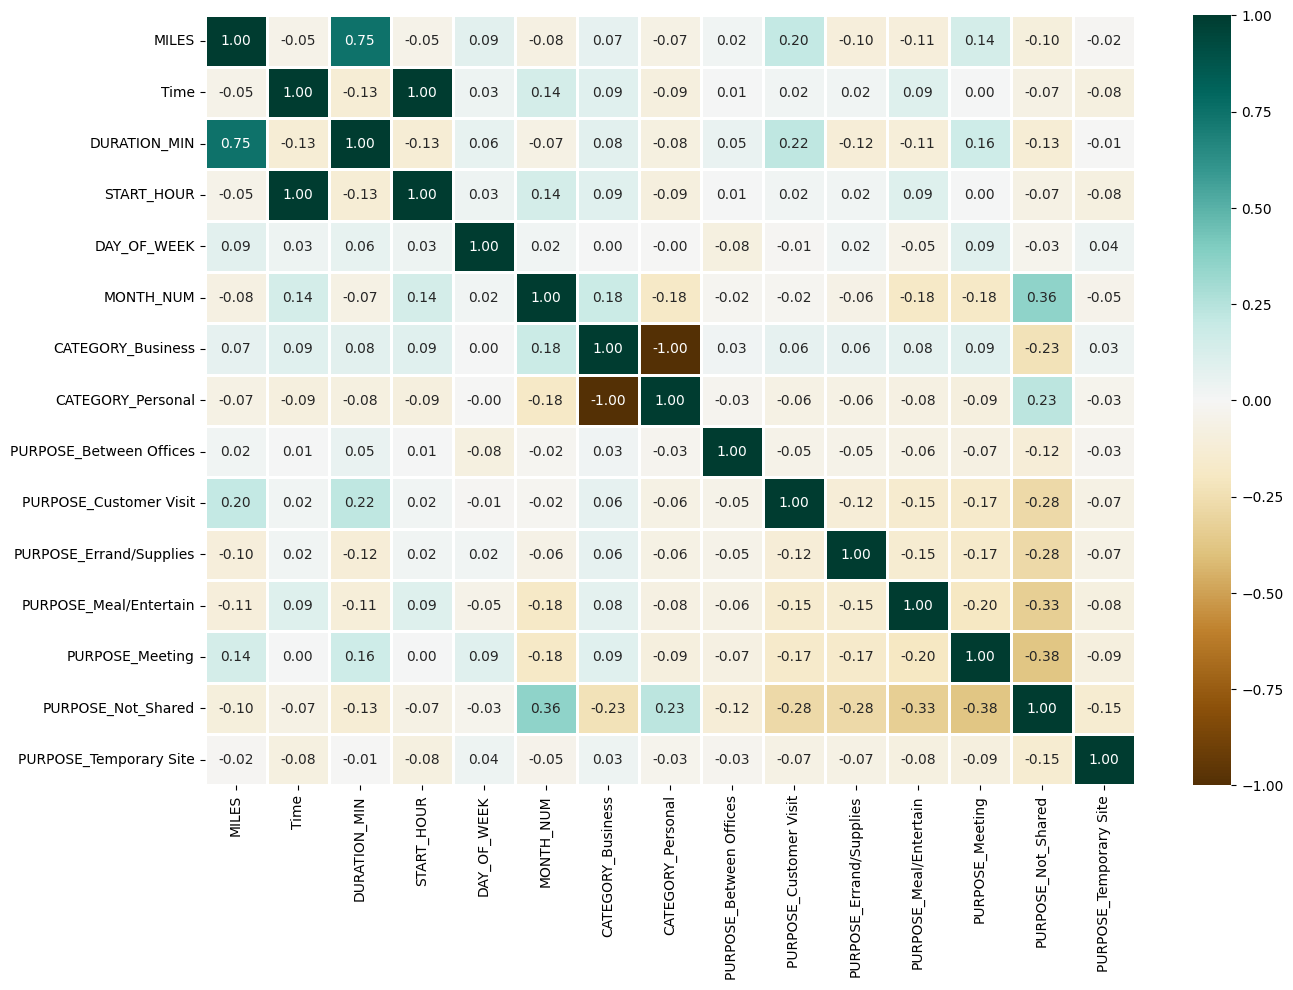

In [ ]:
# Heatmap

numeric_dataset = dataset.select_dtypes(include=['number'])
plt.figure(figsize=(15, 10))
sns.heatmap(numeric_dataset.corr(),
            cmap='BrBG',
            fmt='.2f',
            linewidths=2,
            annot=True)
plt.show()

<Axes: ylabel='MILES'>

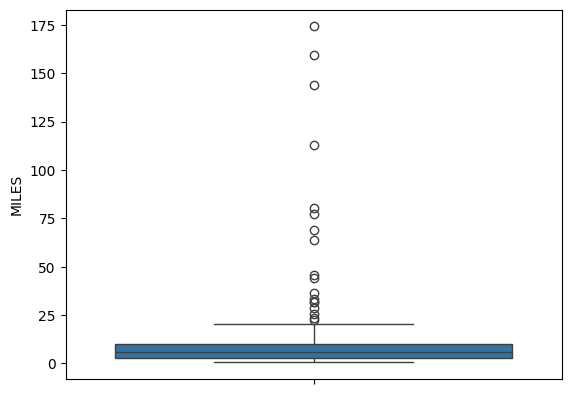

In [ ]:
# Boxploat for MILES

sns.boxplot(dataset['MILES'])

### **Model**

In [ ]:
# Build a clean classification set

df_class = dataset.dropna(subset=['PURPOSE']).copy()
features = ['MILES','DURATION_MIN','START_HOUR','DAY_OF_WEEK','MONTH_NUM','CATEGORY','START','STOP']
X = df_class[features].copy()
y = df_class['PURPOSE'].astype(str).str.strip()
print("Class counts:\n", y.value_counts())

Class counts:
 PURPOSE
Not_Shared         159
Meeting             78
Meal/Entertain      62
Customer Visit      46
Errand/Supplies     45
Temporary Site      14
Between Offices      9
Name: count, dtype: int64


In [ ]:
# One-hot encode categoricals

cat_cols = ['CATEGORY','START','STOP']
num_cols = [c for c in X.columns if c not in cat_cols]
OH = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
OH_df = pd.DataFrame(
    OH.fit_transform(X[cat_cols]),
    index=X.index,
    columns=OH.get_feature_names_out(cat_cols)
)
X_final = pd.concat([X[num_cols].reset_index(drop=True),
                     OH_df.reset_index(drop=True)], axis=1)
classes = sorted(y.unique())
X_final.head()

,MILES,DURATION_MIN,START_HOUR,DAY_OF_WEEK,MONTH_NUM,CATEGORY_Business,CATEGORY_Personal,START_Agnew,START_Apex,START_Arlington,...,STOP_Washington,STOP_Waverly Place,STOP_Wayne Ridge,STOP_West Berkeley,STOP_West Palm Beach,STOP_West University,STOP_Weston,STOP_Westpark Place,STOP_Whitebridge,STOP_Williamsburg Manor
0,5.1,6.0,21,4,1,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,5.0,12.0,1,5,1,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,4.8,13.0,20,5,1,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4.7,14.0,17,1,1,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,63.7,67.0,14,2,1,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
# Train & Test split

X_train, X_test, y_train, y_test = train_test_split(
    X_final, y, test_size=0.2, random_state=42, stratify=y
)

# Replace inf with NaN and impute
X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_test  = X_test.replace([np.inf, -np.inf], np.nan)
imputer = SimpleImputer(strategy='median')
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test  = pd.DataFrame(imputer.transform(X_test),  columns=X_test.columns,  index=X_test.index)
print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (330, 227)  Test: (83, 227)


In [ ]:
# Define 4 models

models = {
    "LogisticRegression": LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42, n_jobs=-1),
    "GradientBoosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(
        objective='multi:softprob',
        eval_metric='mlogloss',
        tree_method='hist',
        random_state=42,
        n_estimators=600,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.9,
        colsample_bytree=0.8
    )
}
list(models.keys())

['LogisticRegression', 'RandomForest', 'GradientBoosting', 'XGBoost']


=== LogisticRegression ===


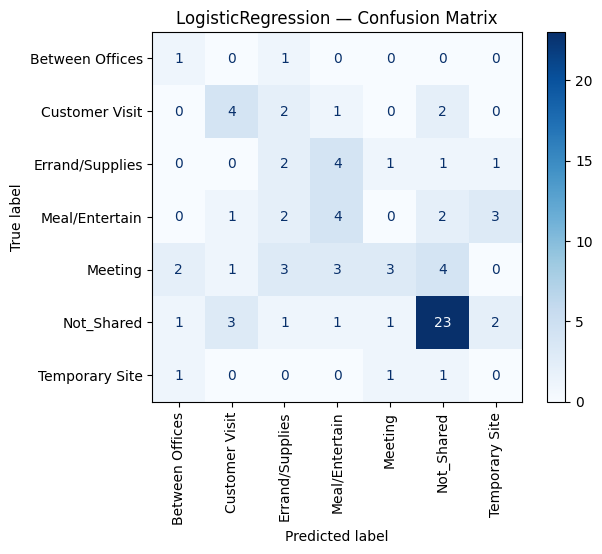


=== RandomForest ===


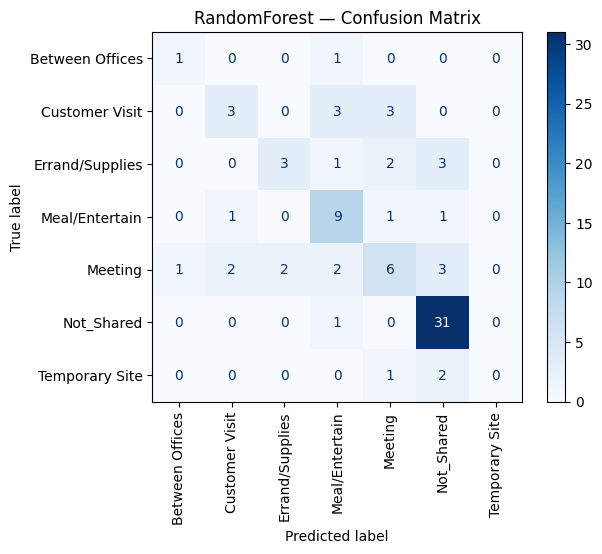


=== GradientBoosting ===


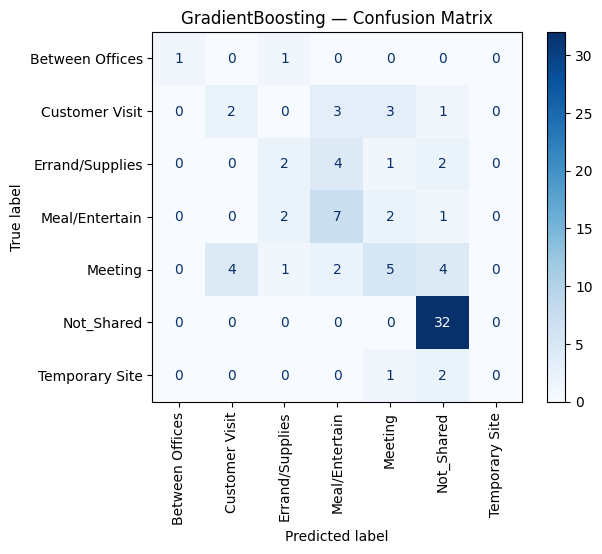


=== XGBoost ===


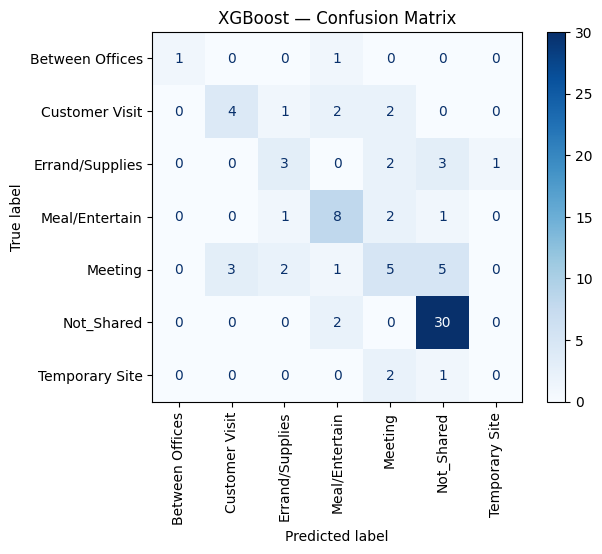

,Model,Accuracy,Precision_weighted,Recall_weighted,F1_weighted,Precision_macro,Recall_macro,F1_macro
1,RandomForest,0.638554,0.595633,0.638554,0.603394,0.480850,0.465774,0.460595
3,XGBoost,0.614458,0.578446,0.614458,0.587673,0.529435,0.456349,0.476459
2,GradientBoosting,0.590361,0.533706,0.590361,0.548473,0.468963,0.405754,0.417430
0,LogisticRegression,0.445783,0.482310,0.445783,0.448448,0.332989,0.343750,0.318654


In [ ]:
# Train & evaluate models

# Encode y for XGBoost (needs integer labels)
le = LabelEncoder()
le.fit(pd.concat([y_train, y_test], axis=0))
y_train_enc = le.transform(y_train)
y_test_enc  = le.transform(y_test)
classes = list(le.classes_)

results = []
all_probas = {}

for name, model in models.items():
    # Fit + predict
    if name == "XGBoost":
        model.fit(X_train, y_train_enc)
        y_pred_enc = model.predict(X_test)
        y_pred = le.inverse_transform(y_pred_enc)
        y_proba = model.predict_proba(X_test)
        all_probas[name] = (classes, y_proba)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test) if hasattr(model, "predict_proba") else None
        if y_proba is not None:
            model_classes = list(getattr(model, "classes_", classes))
            reorder = [model_classes.index(c) for c in classes]
            y_proba = y_proba[:, reorder]
            all_probas[name] = (classes, y_proba)

    acc  = accuracy_score(y_test, y_pred)
    prec_w = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec_w  = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1_w   = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    prec_m = precision_score(y_test, y_pred, average='macro', zero_division=0)
    rec_m  = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1_m   = f1_score(y_test, y_pred, average='macro', zero_division=0)

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision_weighted": prec_w,
        "Recall_weighted": rec_w,
        "F1_weighted": f1_w,
        "Precision_macro": prec_m,
        "Recall_macro": rec_m,
        "F1_macro": f1_m
    })

    # Confusion Matrix
    print(f"\n=== {name} ===")
    cm = confusion_matrix(y_test, y_pred, labels=classes)
    ConfusionMatrixDisplay(cm, display_labels=classes).plot(
        xticks_rotation=90, cmap='Blues', values_format='d'
    )
    plt.title(f"{name} — Confusion Matrix")
    plt.show()

# Results table sorted by F1_weighted
results_df = pd.DataFrame(results).sort_values("F1_weighted", ascending=False)
display(results_df)

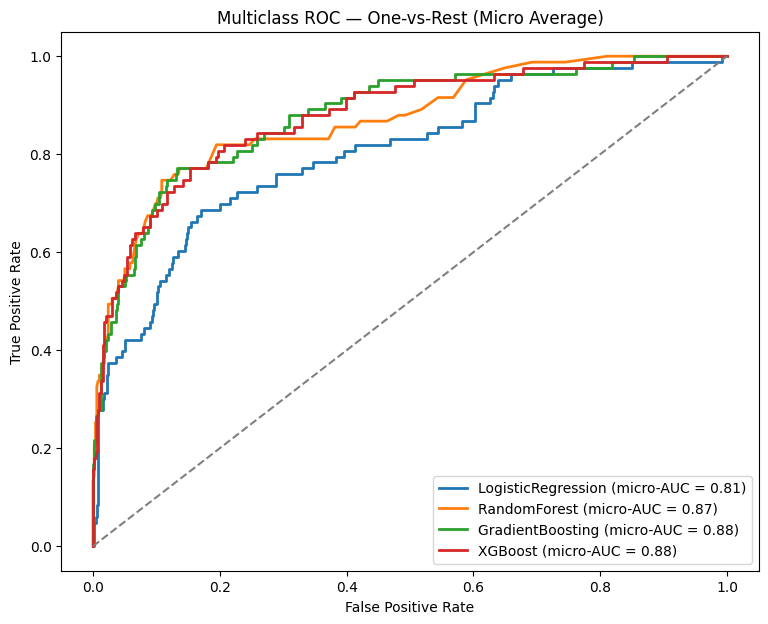

,Model,Accuracy,Precision_weighted,Recall_weighted,F1_weighted,Precision_macro,Recall_macro,F1_macro,ROC_AUC_micro,ROC_AUC_macro_OvR
0,RandomForest,0.638554,0.595633,0.638554,0.603394,0.480850,0.465774,0.460595,0.870905,0.804114
1,XGBoost,0.614458,0.578446,0.614458,0.587673,0.529435,0.456349,0.476459,0.878913,0.820661
2,GradientBoosting,0.590361,0.533706,0.590361,0.548473,0.468963,0.405754,0.417430,0.879615,0.815758
3,LogisticRegression,0.445783,0.482310,0.445783,0.448448,0.332989,0.343750,0.318654,0.805148,0.729939


Best model: RandomForest


In [ ]:
# ROC curves & pick best model

y_test_bin = label_binarize(y_test, classes=classes)

plt.figure(figsize=(9,7))
roc_rows = []

for name, (proba_classes, y_proba) in all_probas.items():
    proba_classes = list(proba_classes)
    reorder = [proba_classes.index(c) for c in classes]
    y_proba_aligned = y_proba[:, reorder]

    fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_proba_aligned.ravel())
    micro_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f"{name} (micro-AUC = {micro_auc:.2f})")

    macro_auc = roc_auc_score(y_test_bin, y_proba_aligned, average='macro', multi_class='ovr')
    roc_rows.append({"Model": name, "ROC_AUC_micro": micro_auc, "ROC_AUC_macro_OvR": macro_auc})

plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC — One-vs-Rest (Micro Average)")
plt.legend(loc="lower right")
plt.show()

roc_df = pd.DataFrame(roc_rows)
if 'results_df' in globals():
    results_df = results_df.merge(roc_df, on="Model", how="left")
else:
    results_df = roc_df.copy()

sort_cols = [c for c in ["F1_weighted", "ROC_AUC_macro_OvR"] if c in results_df.columns]
results_df = results_df.sort_values(sort_cols, ascending=False)
display(results_df)

best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]
print(f"Best model: {best_model_name}")

In [ ]:
# from sklearn.compose import ColumnTransformer
# from sklearn.preprocessing import OneHotEncoder
# from sklearn.model_selection import train_test_split
# from imblearn.over_sampling import SMOTE
# from sklearn.impute import SimpleImputer
# import pandas as pd
# import numpy as np

In [ ]:
# Reuse X, y from your "clean classification set" cell

cat_cols = ['CATEGORY', 'START', 'STOP']
num_cols = [c for c in X.columns if c not in cat_cols]

In [ ]:
# Use One-hot-encoding

preproc_full = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
    ],
    remainder="drop"
)

X_enc = preproc_full.fit_transform(X)

oh = preproc_full.named_transformers_['cat']
feature_names = num_cols + oh.get_feature_names_out(cat_cols).tolist()

X_enc_df = pd.DataFrame(X_enc, columns=feature_names, index=X.index)
X_enc_df.head()

,MILES,DURATION_MIN,START_HOUR,DAY_OF_WEEK,MONTH_NUM,CATEGORY_Business,CATEGORY_Personal,START_Agnew,START_Apex,START_Arlington,...,STOP_Washington,STOP_Waverly Place,STOP_Wayne Ridge,STOP_West Berkeley,STOP_West Palm Beach,STOP_West University,STOP_Weston,STOP_Westpark Place,STOP_Whitebridge,STOP_Williamsburg Manor
0,5.1,6.0,21.0,4.0,1.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,5.0,12.0,1.0,5.0,1.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,4.8,13.0,20.0,5.0,1.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4.7,14.0,17.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,63.7,67.0,14.0,2.0,1.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
# SMOTE effect

sm = SMOTE(random_state=42)
X_sm, y_sm = sm.fit_resample(X_enc_df, y)
print("Shapes after SMOTE:", X_sm.shape, len(y_sm))
print("Class counts after SMOTE:\n", pd.Series(y_sm).value_counts())

Shapes after SMOTE: (1113, 227) 1113
Class counts after SMOTE:
 PURPOSE
Meal/Entertain     159
Not_Shared         159
Errand/Supplies    159
Meeting            159
Customer Visit     159
Temporary Site     159
Between Offices    159
Name: count, dtype: int64


In [ ]:
# Train & test split

X_train, X_test, y_train, y_test = train_test_split(
    X_sm, y_sm, test_size=0.2, random_state=42, stratify=y_sm)
print("Train size:", X_train.shape, " Test size:", X_test.shape)
print("Train class counts:\n", pd.Series(y_train).value_counts())

Train size: (890, 227)  Test size: (223, 227)
Train class counts:
 PURPOSE
Between Offices    128
Meal/Entertain     127
Customer Visit     127
Meeting            127
Not_Shared         127
Errand/Supplies    127
Temporary Site     127
Name: count, dtype: int64


In [ ]:
# Replace inf with NaN and impute median just in case

X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_test  = X_test.replace([np.inf, -np.inf], np.nan)
imputer = SimpleImputer(strategy='median')
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test  = pd.DataFrame(imputer.transform(X_test),  columns=X_test.columns,  index=X_test.index)
print("After imputation -> Train:", X_train.shape, " Test:", X_test.shape)

After imputation -> Train: (890, 227)  Test: (223, 227)


In [ ]:
# Define 4 models

models = {
    "LogisticRegression": LogisticRegression(
        max_iter=2000, random_state=42, multi_class='auto'),
    "RandomForest": RandomForestClassifier(
        n_estimators=300, random_state=42, n_jobs=-1),
    "GradientBoosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(
        objective='multi:softprob',
        eval_metric='mlogloss',
        tree_method='hist',
        random_state=42,
        n_estimators=600,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.9,
        colsample_bytree=0.8)
}
list(models.keys())

['LogisticRegression', 'RandomForest', 'GradientBoosting', 'XGBoost']

In [ ]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# Fit encoder on train+test to lock a stable class order
le = LabelEncoder()
le.fit(pd.concat([y_train, y_test], axis=0))

classes     = list(le.classes_)
y_train_enc = le.transform(y_train)
y_test_enc  = le.transform(y_test)

classes


['Between Offices',
 'Customer Visit',
 'Errand/Supplies',
 'Meal/Entertain',
 'Meeting',
 'Not_Shared',
 'Temporary Site']

In [ ]:
# Rebuild a consistent split

if 'X_sm' in globals() and 'y_sm' in globals():
    src_X = pd.DataFrame(X_sm).reset_index(drop=True)
    src_y = pd.Series(y_sm, name='PURPOSE').reset_index(drop=True)
else:
    src_X = pd.DataFrame(X_train).reset_index(drop=True)
    src_y = pd.Series(y_train, name='PURPOSE').reset_index(drop=True)

X_train, X_test, y_train, y_test = train_test_split(
    src_X, src_y, test_size=0.2, random_state=42, stratify=src_y
)
imputer = SimpleImputer(strategy='median')
X_train_np = imputer.fit_transform(X_train)
X_test_np  = imputer.transform(X_test)

y_train_arr = y_train.astype(str).to_numpy()
y_test_arr  = y_test.astype(str).to_numpy()

le = LabelEncoder()
le.fit(np.concatenate([y_train_arr, y_test_arr]))
classes = list(le.classes_)
y_train_enc = le.transform(y_train_arr)
y_test_enc  = le.transform(y_test_arr)

print("Aligned shapes ->",
      "X_train:", X_train_np.shape, "y_train:", y_train_enc.shape,
      "| X_test:", X_test_np.shape,  "y_test:",  y_test_enc.shape)

Aligned shapes -> X_train: (890, 227) y_train: (890,) | X_test: (223, 227) y_test: (223,)


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



=== LogisticRegression ===


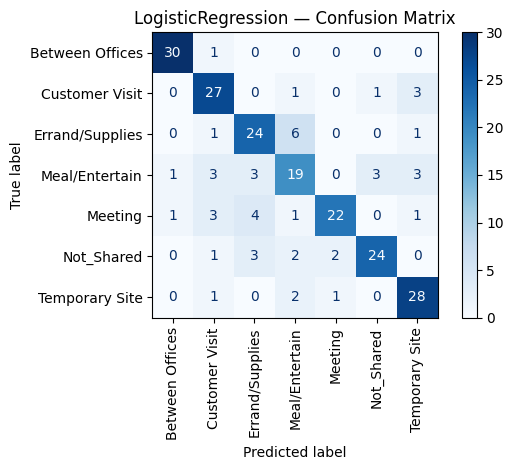


=== RandomForest ===


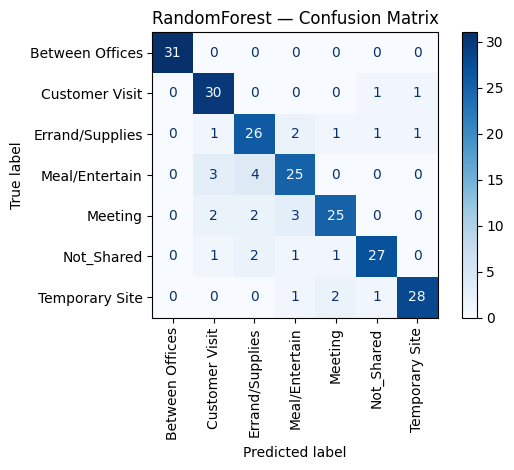


=== GradientBoosting ===


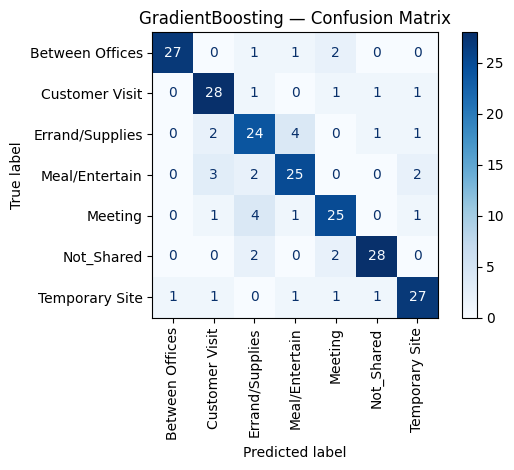


=== XGBoost ===


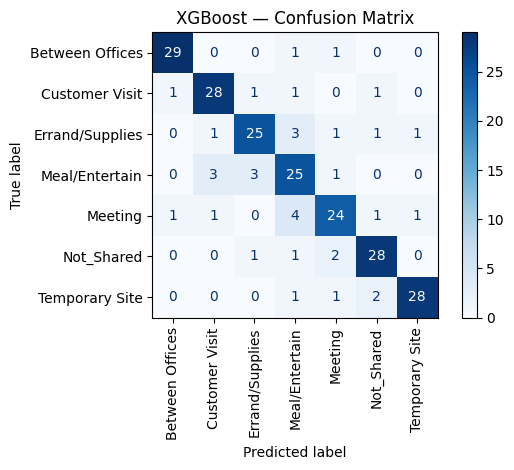

In [ ]:
# Train model and show confusion matrix

results = []
all_probas = {}

for name, model in models.items():
    # Train on encoded y for ALL models
    model.fit(X_train_np, y_train_enc)

    # Predict (encoded) and invert to original labels for reporting
    y_pred_enc = model.predict(X_test_np)
    y_pred = le.inverse_transform(y_pred_enc)

    # Probabilities aligned to global class order (encoded 0..K-1)
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test_np)
        model_classes_enc = getattr(model, "classes_", np.arange(len(classes)))
        idx_map = {c: i for i, c in enumerate(model_classes_enc)}
        aligned = np.zeros((y_proba.shape[0], len(classes)), dtype=float)
        for j in range(len(classes)):
            if j in idx_map:
                aligned[:, j] = y_proba[:, idx_map[j]]
        all_probas[name] = (classes, aligned)

    # Metrics (use original string labels)
    acc   = accuracy_score(y_test_arr, y_pred)
    prec_w = precision_score(y_test_arr, y_pred, average='weighted', zero_division=0)
    rec_w  = recall_score(y_test_arr, y_pred, average='weighted', zero_division=0)
    f1_w   = f1_score(y_test_arr, y_pred, average='weighted', zero_division=0)
    prec_m = precision_score(y_test_arr, y_pred, average='macro', zero_division=0)
    rec_m  = recall_score(y_test_arr, y_pred, average='macro', zero_division=0)
    f1_m   = f1_score(y_test_arr, y_pred, average='macro', zero_division=0)

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision_weighted": prec_w,
        "Recall_weighted": rec_w,
        "F1_weighted": f1_w,
        "Precision_macro": prec_m,
        "Recall_macro": rec_m,
        "F1_macro": f1_m
    })

    print(f"\n=== {name} ===")
    cm = confusion_matrix(y_test_arr, y_pred, labels=classes)
    disp = ConfusionMatrixDisplay(cm, display_labels=classes)
    disp.plot(xticks_rotation=90, cmap='Blues', values_format='d')
    plt.title(f"{name} — Confusion Matrix")
    plt.tight_layout()
    plt.show()

In [ ]:
# Comparison table

results_df = pd.DataFrame(results).sort_values("F1_weighted", ascending=False)
display(results_df)

,Model,Accuracy,Precision_weighted,Recall_weighted,F1_weighted,Precision_macro,Recall_macro,F1_macro
1,RandomForest,0.860987,0.863988,0.860987,0.861174,0.864596,0.861607,0.861794
3,XGBoost,0.838565,0.841518,0.838565,0.839245,0.841938,0.838998,0.839675
2,GradientBoosting,0.825112,0.828658,0.825112,0.826158,0.829264,0.825317,0.826555
0,LogisticRegression,0.780269,0.785168,0.780269,0.779356,0.785848,0.781106,0.780128


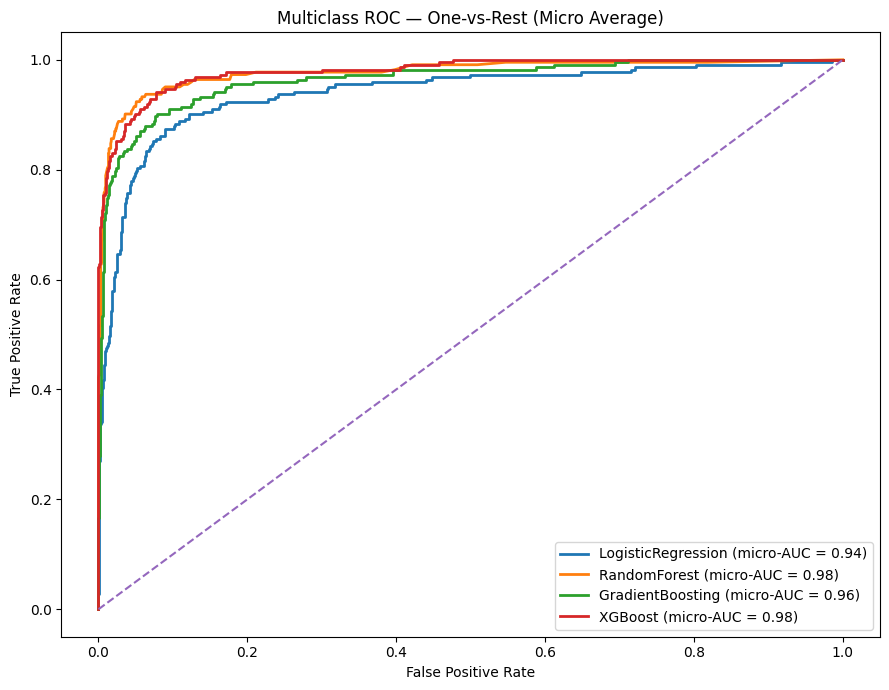

,Model,Accuracy,Precision_weighted,Recall_weighted,F1_weighted,Precision_macro,Recall_macro,F1_macro,ROC_AUC_micro,ROC_AUC_macro_OvR
0,RandomForest,0.860987,0.863988,0.860987,0.861174,0.864596,0.861607,0.861794,0.977304,0.975013
1,XGBoost,0.838565,0.841518,0.838565,0.839245,0.841938,0.838998,0.839675,0.979918,0.977041
2,GradientBoosting,0.825112,0.828658,0.825112,0.826158,0.829264,0.825317,0.826555,0.964367,0.961050
3,LogisticRegression,0.780269,0.785168,0.780269,0.779356,0.785848,0.781106,0.780128,0.940300,0.934662


In [ ]:
# ROC curve

if len(all_probas) == 0:
    print("No probability outputs were collected. Ensure at least one model supports predict_proba.")
else:
    y_test_bin = label_binarize(y_test, classes=classes)

    plt.figure(figsize=(9,7))
    roc_rows = []

    for name, (proba_classes, y_proba) in all_probas.items():
        proba_classes = list(proba_classes)
        reorder = [proba_classes.index(c) for c in classes]
        y_proba_aligned = y_proba[:, reorder]

        fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_proba_aligned.ravel())
        micro_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f"{name} (micro-AUC = {micro_auc:.2f})")

        macro_auc = roc_auc_score(y_test_bin, y_proba_aligned, average='macro', multi_class='ovr')
        roc_rows.append({"Model": name, "ROC_AUC_micro": micro_auc, "ROC_AUC_macro_OvR": macro_auc})

    plt.plot([0,1],[0,1],'--')
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.title("Multiclass ROC — One-vs-Rest (Micro Average)")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

    roc_df = pd.DataFrame(roc_rows)
    results_df = results_df.merge(roc_df, on="Model", how="left")
    results_df = results_df.sort_values(
        [c for c in ["F1_weighted", "ROC_AUC_macro_OvR"] if c in results_df.columns],
        ascending=False, na_position="last"
    )
    display(results_df)

In [ ]:
# Calculate support & confidence

print("\n--- Classification Reports (Support and Confidence) ---")

print("Ensuring models are fitted...")
for name, model in models.items():
    try:
        # Check if fitted by accessing an attribute only available after fitting
        getattr(model, "n_features_in_")
        print(f"{name} is already fitted.")
    except AttributeError:
        print(f"Fitting {name}...")
        model.fit(X_train_np, y_train_enc)


for name, model in models.items():
    print(f"\n=== {name} ===")
    # Get predictions using the fitted model
    y_pred_enc = model.predict(X_test_np)
    y_pred = le.inverse_transform(y_pred_enc)

    # Generate and print the classification report
    # Ensure classification_report is imported (it is in previous cells, but good practice to ensure)
    from sklearn.metrics import classification_report
    import pandas as pd # Ensure pandas is imported

    report = classification_report(y_test_arr, y_pred, target_names=classes, output_dict=True, zero_division=0)

    # Extract and display Support and Precision for each class
    report_df = pd.DataFrame(report).transpose()
    # Select 'support' and 'precision' and rename 'precision' to 'confidence' for display
    report_df_display = report_df[['support', 'precision']].copy()
    report_df_display = report_df_display.rename(columns={'precision': 'confidence'})

    print(report_df_display.to_markdown()) # Print the modified DataFrame


--- Classification Reports (Support and Confidence) ---
Ensuring models are fitted...
LogisticRegression is already fitted.
RandomForest is already fitted.
GradientBoosting is already fitted.
XGBoost is already fitted.

=== LogisticRegression ===
|                 |    support |   confidence |
|:----------------|-----------:|-------------:|
| Between Offices |  31        |     0.9375   |
| Customer Visit  |  32        |     0.72973  |
| Errand/Supplies |  32        |     0.705882 |
| Meal/Entertain  |  32        |     0.612903 |
| Meeting         |  32        |     0.88     |
| Not_Shared      |  32        |     0.857143 |
| Temporary Site  |  32        |     0.777778 |
| accuracy        |   0.780269 |     0.780269 |
| macro avg       | 223        |     0.785848 |
| weighted avg    | 223        |     0.785168 |

=== RandomForest ===
|                 |    support |   confidence |
|:----------------|-----------:|-------------:|
| Between Offices |  31        |     1        |
| Customer

In [ ]:
# Best by F1_weighted, then by ROC_AUC_macro_OvR if available
sort_cols = [c for c in ["F1_weighted", "ROC_AUC_macro_OvR"] if c in results_df.columns]
best_idx = results_df.sort_values(sort_cols, ascending=False).index[0]
best_model_name = results_df.loc[best_idx, "Model"]
best_model = models[best_model_name]

print(f"Best model: {best_model_name}")

dump(best_model, "best_model.pkl")
dump({"classes": classes, "feature_names": list(X_train.columns)}, "model_meta.pkl")
print("Saved: best_model.pkl and model_meta.pkl")

Best model: RandomForest
Saved: best_model.pkl and model_meta.pkl


In [ ]:
# Combine X_sm and y_sm into a single DataFrame
smote_dataset = pd.concat([X_sm, pd.Series(y_sm, name='PURPOSE')], axis=1)

# Save the SMOTE dataset to a CSV file
smote_dataset.to_csv("smote_uber_dataset.csv", index=False)

print("SMOTE dataset saved as smote_uber_dataset.csv")

SMOTE dataset saved as smote_uber_dataset.csv


### **Prediction**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor # Use a regressor for counts
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from joblib import load, dump # To save the new model

import ipywidgets as widgets
from IPython.display import display, Markdown

# Load the SMOTE dataset
try:
    if 'smote_dataset' not in globals():
        dataset = pd.read_csv("smote_uber_dataset.csv")
        print("Loaded smote_uber_dataset.csv for trip count prediction.")
    else:
        dataset = smote_dataset
        print("Reusing smote_dataset from previous cells for trip count prediction.")

    # Ensure 'HOUR' and 'DAYOFWEEK' columns are integers before creating the combined string
    dataset['START_HOUR'] = dataset['START_HOUR'].astype(int, errors='ignore')
    dataset['DAY_OF_WEEK'] = dataset['DAY_OF_WEEK'].astype(int, errors='ignore')

    # Create a unique identifier for each hour/day combination
    dataset['HOUR_DAY'] = dataset['START_HOUR'].astype(str) + '_' + dataset['DAY_OF_WEEK'].astype(str)

    # Count trips for each hour/day combination
    trip_counts = dataset['HOUR_DAY'].value_counts().reset_index()
    trip_counts.columns = ['HOUR_DAY', 'TRIP_COUNT']

    # Split the aggregated key back into HOUR and DAYOFWEEK for modeling
    trip_counts[['START_HOUR', 'DAY_OF_WEEK']] = trip_counts['HOUR_DAY'].str.split('_', expand=True)
    trip_counts['START_HOUR'] = trip_counts['START_HOUR'].astype(int)
    trip_counts['DAY_OF_WEEK'] = trip_counts['DAY_OF_WEEK'].astype(int)

    # Features (X) and Target (y) for the new prediction task
    X_trip = trip_counts[['START_HOUR', 'DAY_OF_WEEK']]
    y_trip = trip_counts['TRIP_COUNT']

    # Train a RandomForestRegressor model
    # Always train a new regressor for this task, avoid reusing the classifier 'model'
    trip_count_model = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
    print("Training RandomForestRegressor model for trip count...")
    trip_count_model.fit(X_trip, y_trip)
    print("RandomForestRegressor model trained.")
    dump(trip_count_model, "smote_trip_count_model.pkl") # Save with a different name to distinguish
    print("Trained model saved as smote_trip_count_model.pkl")

except FileNotFoundError:
    print("smote_uber_dataset.csv not found. Cannot train trip count model.")
    trip_count_model = None # Set model to None if data is not found
except Exception as e:
    print(f"Error during trip count model training or saving: {e}")
    trip_count_model = None

# Define options for dropdowns (using available data if model trained)
if trip_count_model is not None:
    day_options = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    # Use hours from the training data if available, otherwise use a default range
    hour_options = list(range(24)) # Use all hours from 0 to 23
else:
    # Fallback options if model was not trained
    day_options = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    hour_options = list(range(24))

# Create widgets
day_dropdown = widgets.Dropdown(options=day_options, description='Day:')
hour_dropdown = widgets.Dropdown(options=hour_options, description='Start_Hour:')
predict_button = widgets.Button(description='Predict Trip Count')
output_widget = widgets.Output()

# Load the trained model once if possible
try:
    loaded_model = load("smote_trip_count_model.pkl")
    print("Loaded smote_trip_count_model.pkl for prediction.")
except FileNotFoundError:
    print("smote_trip_count_model.pkl not found. Prediction will not work.")
    loaded_model = None
except Exception as e:
    print(f"Error loading smote_trip_count_model.pkl: {e}")
    loaded_model = None

def predict_trip_count(b):
    with output_widget:
        output_widget.clear_output() # Clear previous output
        print("Predicting trip count...") # Add a message to confirm function call

        if loaded_model is None:
            print("Prediction model not loaded. Cannot predict.")
            return

        # Get selected values from widgets
        day_name = day_dropdown.value
        time_hour = hour_dropdown.value

        # Map day name to DAYOFWEEK (0=Monday, 6=Sunday)
        day_map = {
            'Monday': 0, 'Tuesday': 1, 'Wednesday': 2, 'Thursday': 3,
            'Friday': 4, 'Saturday': 5, 'Sunday': 6
        }
        dayofweek = day_map.get(day_name)

        if dayofweek is None:
            print("Invalid day name selected.")
            return

        # Create a DataFrame for the user input with correct column names
        user_data = pd.DataFrame([[time_hour, dayofweek]], columns=['START_HOUR', 'DAY_OF_WEEK'])

        try:
            # Make prediction
            predicted_count = loaded_model.predict(user_data)

            # The prediction is a float, convert to integer for car count
            estimated_cars = int(round(predicted_count[0]))

            print(f"\nEstimated number of booked orders (cars needed) at this time: {estimated_cars}")
        except Exception as e:
            print(f"Error during prediction: {e}")


# Link the button click to the prediction function
predict_button.on_click(predict_trip_count)

# Display the widgets if the model was loaded successfully
if loaded_model is not None:
    display(Markdown("### Predict Trip Count\nSelect the Day and Hour to estimate the number of trips."))
    display(day_dropdown, hour_dropdown, predict_button, output_widget)
else:
     display(Markdown("### Predict Trip Count\nCannot display prediction widgets as the model was not loaded."))

Reusing smote_dataset from previous cells for trip count prediction.
Training RandomForestRegressor model for trip count...
RandomForestRegressor model trained.
Trained model saved as smote_trip_count_model.pkl
Loaded smote_trip_count_model.pkl for prediction.


### Predict Trip Count
Select the Day and Hour to estimate the number of trips.

Dropdown(description='Day:', options=('Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sun…

Dropdown(description='Start_Hour:', options=(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18,…

Button(description='Predict Trip Count', style=ButtonStyle())

Output()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from joblib import load, dump

import ipywidgets as widgets
from IPython.display import display

# Load the original dataset for duration prediction
try:
    dataset = pd.read_csv("UberDataset.csv")
except FileNotFoundError:
    print("UberDataset.csv not found. Please ensure the dataset is in the correct directory.")
    dataset = None

if dataset is not None:

    # Convert dates to datetime objects
    dataset['START_DATE'] = pd.to_datetime(dataset['START_DATE'], errors='coerce')
    dataset['END_DATE'] = pd.to_datetime(dataset['END_DATE'], errors='coerce')

    # Extract Day of Week and Hour
    dataset['DAYOFWEEK'] = dataset['START_DATE'].dt.dayofweek  # 0=Mon
    dataset['HOUR'] = dataset['START_DATE'].dt.hour

    # Features (X) and Target (y)
    features = ['START', 'STOP', 'DAYOFWEEK', 'HOUR']
    target = 'DURATION_MIN'

    # Calculate DURATION_MIN from START_DATE and END_DATE
    dataset['DURATION_MIN'] = (dataset['END_DATE'] - dataset['START_DATE']).dt.total_seconds()/60


    # Drop rows where target or features are missing
    dataset.dropna(subset=features + [target], inplace=True)

    X = dataset[features]
    y = dataset[target]

    # Identify categorical and numerical columns for preprocessing
    cat_cols = ['START', 'STOP']
    num_cols = ['DAYOFWEEK', 'HOUR']

    # Create a preprocessor using ColumnTransformer
    # One-hot encode categorical features, scale numerical features
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), num_cols), # Scale numerical features
            ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols) # One-hot encode categorical features
        ],
        remainder='drop' # Drop other columns not specified
    )

    # Create a pipeline with preprocessing and the RandomForestRegressor model
    model_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1))
    ])

    # Train the pipeline
    model_pipeline.fit(X, y)
    print("RandomForestRegressor model trained on original data for trip duration prediction.")

    # Save the trained pipeline and feature names
    dump(model_pipeline, "duration_prediction_model.pkl")

    # To save feature names after preprocessing (useful for consistent input)
    # Fit the preprocessor separately to get the transformed feature names
    preprocessor.fit(X)
    feature_names_out = preprocessor.get_feature_names_out()
    dump(feature_names_out, "duration_model_feature_names.pkl")

    print("Trained pipeline and feature names saved.")


    # --- Prediction Function with Interactive Widgets ---

    # Get unique start and stop locations for dropdowns
    start_locations = sorted(dataset['START'].unique().tolist())
    stop_locations = sorted(dataset['STOP'].unique().tolist())
    day_options = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    hour_options = list(range(24))


    # Create widgets
    start_dropdown = widgets.Dropdown(options=start_locations, description='Start_location:')
    stop_dropdown = widgets.Dropdown(options=stop_locations, description='Stop_location:')
    day_dropdown = widgets.Dropdown(options=day_options, description='Day:')
    hour_dropdown = widgets.Dropdown(options=hour_options, description='Start_Hour:')
    predict_button = widgets.Button(description='Predict Duration')
    output_widget = widgets.Output()


    def predict_duration(b):
        with output_widget:
            output_widget.clear_output() # Clear previous output

            # Get selected values from widgets
            start_location = start_dropdown.value
            stop_location = stop_dropdown.value
            day_name = day_dropdown.value
            time_hour = hour_dropdown.value

            # Check if start and stop locations are the same
            if start_location == stop_location:
                print("Start and Stop locations cannot be the same for duration prediction.")
                return

            # Map day name to DAYOFWEEK (0=Monday, 6=Sunday)
            day_map = {
                'Monday': 0, 'Tuesday': 1, 'Wednesday': 2, 'Thursday': 3,
                'Friday': 4, 'Saturday': 5, 'Sunday': 6
            }
            dayofweek = day_map.get(day_name)

            if dayofweek is None:
                print("Invalid day name selected.")
                return

            # Create a DataFrame for the user input, matching the training features structure
            user_data = pd.DataFrame([[start_location, stop_location, dayofweek, time_hour]],
                                     columns=features)

            # Load the trained pipeline (if not already loaded)
            try:
                loaded_pipeline = load("duration_prediction_model.pkl")
            except FileNotFoundError:
                print("Trained duration model not found. Please run the training part first.")
                loaded_pipeline = None

            if loaded_pipeline:
                # Make prediction using the pipeline
                predicted_duration = loaded_pipeline.predict(user_data)

                print(f"\nEstimated trip duration: {predicted_duration[0]:.2f} minutes")

    # Link the button click to the prediction function
    predict_button.on_click(predict_duration)

    # Display the widgets
    print("\nPlease provide the following details for trip duration prediction:")
    display(start_dropdown, stop_dropdown, day_dropdown, hour_dropdown, predict_button, output_widget)

RandomForestRegressor model trained on original data for trip duration prediction.
Trained pipeline and feature names saved.

Please provide the following details for trip duration prediction:


Dropdown(description='Start_location:', options=('Agnew', 'Apex', 'Arlington', 'Arlington Park at Amberly', 'B…

Dropdown(description='Stop_location:', options=('Agnew', 'Apex', 'Arlington', 'Arlington Park at Amberly', 'Ar…

Dropdown(description='Day:', options=('Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sun…

Dropdown(description='Start_Hour:', options=(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18,…

Button(description='Predict Duration', style=ButtonStyle())

Output()